# 第3章 FrozenLake：表で覚える強化学習

凍った湖の上に、4 × 4 のマス目があります。左上のスタートから、右下のゴールまで歩いて渡るのが目標です。ところどころに氷の割れた穴があり、落ちたらそこで終わりです。しかも氷は滑ります。右へ進もうとしても、思った向きに進めるのは 3 回に 1 回ほどで、残りは横へ滑ってしまいます。どの向きへ進もうとすれば、穴に落ちずにゴールへ着ける見込みが高くなるでしょうか。

この章では、この **FrozenLake** を、表を使う強化学習で解きます。マス目は 16 個、行動は上下左右の 4 つだけなので、「このマスでこの向きへ進むと、どれだけ良いか」を 16 × 4 の表に書き込んで覚えられます。まず、用意したサンプルのプログラム（Q学習）を動かして、でたらめに歩くとほとんどゴールに着けないエージェントが、試行錯誤だけでゴールに着けるようになる様子を楽しみます。次に、サンプルを読んで、表を書き換える1行が何をしているのかを確かめます。最後に、湖の仕組み（どこへどれだけの確率で滑るか）が分かっている場合に、歩き回らずに計算だけで答えを出す方法（価値反復）と比べます。

- **前提**: [第2章 Gymnasium の API の基本](../ch02_gymnasium_api/ch02_gymnasium_api.ipynb)と、概要資料の[強化学習](../../overview/rl.md)を読んでいること
- **所要の目安**: 実行は CPU で 1 分ほど
- **使う装置**: CPU だけで動きます（ニューラルネットワークは使いません。計算は NumPy だけです）

> **注記**
> - **出力の出どころ**: この Notebook に残っている出力は、著者の環境（Windows 11、CPU のみ、Gymnasium 1.3.0、NumPy 2.5.3）で 2026-10-09 に実行したものです。各セルの出力がそのまま期待する結果で、直後の「期待する結果」の段落に読み方を書いています。
> - **進め方**: セルを上から順に実行します。サンプルのプログラムは、読んで書き写す必要はありません。動かして、読んで、数字を変えて遊んでください。

## 0. 学習目標と完了条件

この章を終えると、次のことができるようになります。

1. FrozenLake の状態・行動・報酬と、「滑る」ことの意味を説明できる
2. 用意した Q学習のサンプルを動かし、学習前と学習後の成績（ゴールに着いた割合）を比べられる
3. Q 表を読み、各マスでどの向きへ進むのが良いと学んだかを図で確かめられる
4. Q学習の更新の式が、サンプルのどの1行に当たるかを説明できる
5. 湖の仕組みが分かっている場合の解き方（価値反復・方策反復）と、Q学習の違いを説明できる

完了条件は、この Notebook を上から最後まで実行して、4節の Q学習で学んだ方策と、7節の価値反復で求めた方策が、どちらもゴールに着く割合 70% を超えることです（Gymnasium は、FrozenLake の 4 × 4 の湖を「解けた」とみなす目安を、報酬の平均 0.7 としています）。

## 1. 全体像

この章の流れは次のとおりです。

| 節 | すること | 見るもの |
|---|---|---|
| 3節 | FrozenLake を知る | 地図、滑り方、でたらめに歩いたときの成績 |
| 4節 | 動かして楽しむ：Q学習のサンプルを動かす | 学習後の成績、歩く様子、学習曲線 |
| 5節 | 読む(1)：Q 表 | 各マスで学んだ向き |
| 6節 | 読む(2)：Q学習のサンプル | 表を書き換える1行の意味 |
| 7節 | 読む(3)：湖の仕組みが分かっているとき | 価値反復・方策反復と Q学習の比較 |
| 8節 | 遊んでみる | 滑らない湖、割引率、大きな湖 |

この章で扱う手法は、概要資料の[強化学習の手法の地図](../../overview/rl.md)の左側、「表で覚える」領域にあります。4〜6節の Q学習は、湖の仕組みを使わずに経験だけから学ぶ**モデルフリー**の手法、7節の価値反復・方策反復は、湖の仕組み（モデル）を使って計算する**モデルベース**の手法です。

ここで使う言葉を、先に確かめておきます。

- **状態**: エージェントが今いるマスの番号（0〜15）。第2章の CartPole では4つの実数でしたが、FrozenLake では整数1つです
- **Q 値**（行動価値）: ある状態である行動を選び、その後も良い行動を続けたときに見込める収益（これから先に得る報酬の合計。概要資料の2節）
- **Q 表**: 状態と行動のすべての組の Q 値を並べた表。FrozenLake では 16 行 × 4 列

## 2. 準備

使うライブラリを読み込み、この章で何度も使う2つの関数を用意します。

In [1]:
import itertools
import time
from pathlib import Path

import gymnasium as gym
import imageio
import matplotlib.pyplot as plt
import numpy as np

FIGURES = Path("figures")
FIGURES.mkdir(exist_ok=True)

ACTION_NAMES = ["LEFT", "DOWN", "RIGHT", "UP"]  # 行動の番号 0〜3 の意味
ARROWS = [(-1, 0), (0, 1), (1, 0), (0, -1)]  # 行動ごとの矢印の向き（図の上で、右と下が正）
TILE_COLORS = {"S": "#cfe8f7", "F": "#eef7fc", "H": "#1f4e79", "G": "#f2c14e"}


# 湖の地図を描く。state を渡すとその位置に赤い丸を、values・policy を渡すと各マスに値と矢印を書く
def draw_lake(ax, desc, state=None, values=None, policy=None, numbers=False, title=None):
    n_rows, n_cols = desc.shape
    for row, col in itertools.product(range(n_rows), range(n_cols)):
        letter = desc[row, col].decode()
        s = row * n_cols + col
        ax.add_patch(plt.Rectangle((col, row), 1, 1, facecolor=TILE_COLORS[letter], edgecolor="gray"))
        color = "white" if letter == "H" else "black"
        if numbers:
            ax.text(col + 0.06, row + 0.28, str(s), fontsize=8, color=color)
        if letter in "HG" or (values is None and policy is None):
            ax.text(col + 0.5, row + 0.55, letter, ha="center", va="center", fontsize=12, color=color)
        if values is not None and letter in "SF":
            ax.text(col + 0.5, row + 0.9, f"{values[s]:.2f}", ha="center", fontsize=8)
        if policy is not None and letter in "SF":
            dx, dy = ARROWS[policy[s]]
            ax.annotate("", xy=(col + 0.5 + 0.28 * dx, row + 0.45 + 0.28 * dy),
                        xytext=(col + 0.5 - 0.28 * dx, row + 0.45 - 0.28 * dy),
                        arrowprops=dict(arrowstyle="->", lw=1.8, color="dimgray"))
    if state is not None:
        row, col = divmod(int(state), n_cols)
        ax.add_patch(plt.Circle((col + 0.5, row + 0.5), 0.22, color="tab:red", zorder=3))
    ax.set_xlim(0, n_cols)
    ax.set_ylim(n_rows, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    if title:
        ax.set_title(title)


# 方策（状態の番号ごとに選ぶ行動を並べた配列）で episodes 回歩かせ、ゴールに着いた割合を返す
def success_rate(env, policy, episodes=1000, seed=100):
    goals = 0
    for i in range(episodes):
        state, info = env.reset(seed=seed if i == 0 else None)
        while True:
            state, reward, terminated, truncated, info = env.step(int(policy[state]))
            if terminated or truncated:
                goals += reward
                break
    return goals / episodes

関数の説明:

- `draw_lake` は、湖の地図を matplotlib で描く関数です。マスの色は、スタート（`S`）が薄い水色、凍った床（`F`）が白に近い水色、穴（`H`）が紺、ゴール（`G`）が黄色です。エージェントの位置（赤い丸）、各マスの値（数）、各マスで選ぶ向き（矢印）を書き込めます
- `success_rate` は、方策でエピソードを 1,000 回繰り返し、ゴールに着いた割合を返す関数です。最初の `reset` にだけ `seed` を渡しています。2回目からは `seed` を渡さずに `reset` を呼ぶと、最初に決めた乱数の続きが使われるので、1,000 回全体の滑り方が `seed` で決まり、何度実行しても同じ結果になります

Gymnasium にも FrozenLake の絵を描く機能（第0章で CartPole に使った `render_mode="rgb_array"`）がありますが、その絵には、Gymnasium のライセンスとは別の作者の画像素材（エルフなど）が使われています。この教科書では、その絵を載せずに、`draw_lake` で描いた図を使います。

## 3. FrozenLake を知る

### 3-1. 環境を作る

In [2]:
env = gym.make("FrozenLake-v1")
print(env)
print("エピソードの上限の回数:", env.spec.max_episode_steps)
print("「解けた」とみなす報酬の目安:", env.spec.reward_threshold)
print("観測の空間:", env.observation_space)
print("行動の空間:", env.action_space)
desc = env.unwrapped.desc
print(desc)

<TimeLimit<OrderEnforcing<PassiveEnvChecker<FrozenLakeEnv<FrozenLake-v1>>>>>
エピソードの上限の回数: 100
「解けた」とみなす報酬の目安: 0.7
観測の空間: Discrete(16)
行動の空間: Discrete(4)
[[b'S' b'F' b'F' b'F']
 [b'F' b'H' b'F' b'H']
 [b'F' b'F' b'F' b'H']
 [b'H' b'F' b'F' b'G']]


**期待する結果**（上の出力の読み方）: 1行目から、第2章の CartPole と同じように、本体の `FrozenLakeEnv` を3つのラッパーが包んでいることが分かります。エピソードの上限は 100 回で、100 回歩いてもゴールにも穴にも着かなければ、`truncated` で打ち切られます。「解けた」とみなす目安は報酬 0.7 です。

観測の空間は `Discrete(16)` で、エージェントのいるマスの番号（0〜15）を表します。行動の空間は `Discrete(4)` で、0 が左（`LEFT`）、1 が下（`DOWN`）、2 が右（`RIGHT`）、3 が上（`UP`）です。

最後の配列 `desc` は湖の地図で、`S` がスタート、`F` が凍った床（Frozen）、`H` が穴（Hole）、`G` がゴールです（`b'S'` の `b` は、文字がバイト列として入っていることを表す印です）。

### 3-2. 地図を見る

16 個のマスに番号を振って描きます。番号は、左上の 0 から右へ数え、行の終わりで次の行の左端へ移ります。

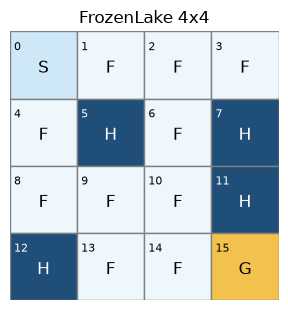

In [3]:
fig, ax = plt.subplots(figsize=(3.2, 3.2))
draw_lake(ax, desc, numbers=True, title="FrozenLake 4x4")
fig.tight_layout()
fig.savefig(FIGURES / "ch03_map.png", dpi=80)
plt.show()

**期待する結果**（上の出力の読み方）: 4 × 4 のマス目に、番号と文字を書いた地図が出ます。穴（紺）は 5・7・11・12 の4つです。スタートの 0 からゴールの 15 へは、上下左右に1マスずつ進んで、最短でも 6 歩かかります。

報酬は、ゴールに着いたときだけ 1 で、それ以外は 0 です。穴に落ちるかゴールに着くと、`terminated` でエピソードが終わります。報酬の合計は、ゴールに着いた回は 1、着かなかった回は 0 なので、報酬の平均はそのまま「ゴールに着いた割合」になります。

### 3-3. 氷の上で滑る

FrozenLake の既定では、氷が滑ります（`is_slippery=True`）。スタート（状態 0）で右（`RIGHT`、行動 2）を選ぶ、という1歩を 1,000 回試して、どのマスへ行ったかを数えます。

In [4]:
counts = np.zeros(16, dtype=int)
env.reset(seed=0)
for _ in range(1000):
    env.reset()
    state, reward, terminated, truncated, info = env.step(2)  # RIGHT
    counts[state] += 1
for s in np.flatnonzero(counts):
    print(f"状態 {s:2d} へ: {counts[s]} 回")

状態  0 へ: 344 回
状態  1 へ: 328 回
状態  4 へ: 328 回


**期待する結果**（上の出力の読み方）: 状態 0 で右を選んだ 1,000 回のうち、右隣の 1 へ進めたのは 328 回で、およそ3分の1です。残りは、下の 4 へ滑った回（328 回）と、上へ滑ろうとしたものの湖の外へは出られずに 0 にとどまった回（344 回）です。

滑る湖では、選んだ向きへ進めるのは確率 1/3 で、選んだ向きから見て左右の向き（右を選んだなら上と下）へ、それぞれ確率 1/3 で滑ります。選んだ向きの反対へは滑りません。この確率の表は、7-1節で Gymnasium から読み出します。

### 3-4. でたらめに歩く

でたらめに行動を選んで 1,000 回歩かせ、ゴールに着いた割合を測ります。

In [5]:
env.action_space.seed(100)
goals = 0
for i in range(1000):
    state, info = env.reset(seed=100 if i == 0 else None)
    while True:
        state, reward, terminated, truncated, info = env.step(env.action_space.sample())
        if terminated or truncated:
            goals += reward
            break
random_rate = goals / 1000
print(f"でたらめに歩いてゴールに着いた割合: {random_rate:.1%}")

でたらめに歩いてゴールに着いた割合: 1.7%


**期待する結果**（上の出力の読み方）: でたらめに歩くと、1,000 回のうちゴールに着けたのは 17 回（1.7%）だけです。

## 4. 動かして楽しむ：Q学習のサンプルを動かす

### 4-1. 学習させる

用意した Q学習のサンプルで、エピソードを 5,000 回経験させます。サンプルの中身は6節で読むので、ここでは実行して結果を見てください。

In [6]:
# 状態 state で Q 値が最大の行動を1つ返す（最大の行動が複数あれば、その中からでたらめに選ぶ）
def greedy_action(q_table, state, rng):
    best = np.flatnonzero(q_table[state] == q_table[state].max())
    return int(rng.choice(best))


# Q学習で episodes 回のエピソードを経験させ、Q 表と、エピソードごとの報酬の一覧を返す
def q_learning(env, episodes, alpha=0.1, gamma=0.99, epsilon=0.1, seed=0):
    rng = np.random.default_rng(seed)
    q_table = np.zeros((env.observation_space.n, env.action_space.n))
    rewards = np.zeros(episodes)
    for i in range(episodes):
        state, info = env.reset(seed=seed if i == 0 else None)
        while True:
            # ε-greedy: 確率 epsilon ででたらめに、残りは Q 値が最大の行動を選ぶ
            if rng.random() < epsilon:
                action = int(rng.integers(env.action_space.n))
            else:
                action = greedy_action(q_table, state, rng)
            next_state, reward, terminated, truncated, info = env.step(action)
            # 目標: 今の報酬 + 割引した「次の状態での最大の Q 値」（terminated なら先が無いので報酬だけ）
            target = reward if terminated else reward + gamma * q_table[next_state].max()
            q_table[state, action] += alpha * (target - q_table[state, action])
            rewards[i] += reward
            state = next_state
            if terminated or truncated:
                break
    return q_table, rewards


start = time.perf_counter()
q_table, train_rewards = q_learning(env, episodes=5000)
print(f"学習にかかった時間: {time.perf_counter() - start:.1f} 秒")
print(f"学習中、最初の 500 回でゴールに着いた割合: {train_rewards[:500].mean():.1%}")
print(f"学習中、最後の 500 回でゴールに着いた割合: {train_rewards[-500:].mean():.1%}")

学習にかかった時間: 3.9 秒
学習中、最初の 500 回でゴールに着いた割合: 5.8%
学習中、最後の 500 回でゴールに着いた割合: 39.4%


**期待する結果**（上の出力の読み方）: 学習は著者の環境で 3.9 秒でした（パソコンによって変わります）。学習中にゴールに着いた割合は、最初の 500 回の 5.8% から、最後の 500 回の 39.4% まで上がりました。学習の seed を固定しているので、同じ版のライブラリなら、時間以外は何度実行しても同じ結果になります。

### 4-2. 成績を測る

学習した Q 表から、各マスで Q 値が最大の行動を選ぶ方策を作り、3-4節と同じ条件（1,000 回、`seed=100`）で歩かせます。学習中とは違い、ここではでたらめな行動を混ぜません。

In [7]:
q_policy = q_table.argmax(axis=1)
q_rate = success_rate(env, q_policy)
print(f"でたらめに歩いた場合: {random_rate:.1%}")
print(f"学習後の方策の場合:   {q_rate:.1%}")

でたらめに歩いた場合: 1.7%
学習後の方策の場合:   73.6%


**期待する結果**（上の出力の読み方）: 学習後の方策は、1,000 回のうち 73.6% でゴールに着きました。でたらめに歩いた場合（1.7%）の 40 倍あまりで、Gymnasium の「解けた」の目安（0.7）も超えています。

`q_table.argmax(axis=1)` は、Q 表の各行（各状態）で、Q 値が最大の列（行動）の番号を並べた配列を返します。これが学習後の方策で、`q_policy[状態]` で、その状態で選ぶ行動が分かります。

### 4-3. 歩く様子を見る

学習後の方策で歩かせ、ゴールに着いた回の様子を GIF に保存します。`seed` を 0 から順に試して、最初にゴールに着いた回を使います。

In [8]:
# 方策で1エピソード歩かせ、(状態, 選んだ行動) の一覧と、最後の状態と、最後の報酬を返す
def record_walk(env, policy, seed):
    state, info = env.reset(seed=seed)
    steps = []
    while True:
        action = int(policy[state])
        steps.append((state, action))
        state, reward, terminated, truncated, info = env.step(action)
        if terminated or truncated:
            return steps, state, reward


for seed in itertools.count():
    walk, last_state, reward = record_walk(env, q_policy, seed)
    if reward == 1:
        break
print("ゴールに着いた seed:", seed, " かかった回数:", len(walk))
print("通った道（状態 → 選んだ向き）:")
print(", ".join(f"{s}→{ACTION_NAMES[a]}" for s, a in walk), "→", last_state)

# 1歩ごとの図を作り、GIF に保存する
states = [s for s, _ in walk] + [last_state]
frames = []
for t, s in enumerate(states):
    fig, ax = plt.subplots(figsize=(3.2, 3.4), dpi=80)
    draw_lake(ax, desc, state=s, policy=q_policy, title=f"t = {t}")
    fig.canvas.draw()
    frames.append(np.asarray(fig.canvas.buffer_rgba())[:, :, :3].copy())
    plt.close(fig)
imageio.v3.imwrite(FIGURES / "ch03_walk.gif", frames + [frames[-1]] * 5, duration=300, loop=0)
print("GIF の枚数:", len(frames) + 5)

ゴールに着いた seed: 1  かかった回数: 41
通った道（状態 → 選んだ向き）:
0→LEFT, 4→LEFT, 0→LEFT, 4→LEFT, 0→LEFT, 0→LEFT, 4→LEFT, 4→LEFT, 4→LEFT, 0→LEFT, 4→LEFT, 4→LEFT, 0→LEFT, 4→LEFT, 0→LEFT, 0→LEFT, 0→LEFT, 0→LEFT, 0→LEFT, 0→LEFT, 4→LEFT, 0→LEFT, 0→LEFT, 4→LEFT, 8→UP, 8→UP, 4→LEFT, 0→LEFT, 0→LEFT, 4→LEFT, 4→LEFT, 0→LEFT, 0→LEFT, 4→LEFT, 4→LEFT, 8→UP, 9→DOWN, 13→RIGHT, 14→DOWN, 13→RIGHT, 14→DOWN → 15


GIF の枚数: 47


**期待する結果**（上の出力の読み方。seed = 1 の場合）: seed = 0 の回はゴールに着けず、seed = 1 の回で、41 回目にゴールに着きました。通った道を見ると、最初の 35 回は、左上の状態 0・4・8 の間を行ったり来たりしています。0 と 4 では、どちらも `LEFT` を選んでいます。左は湖の端なので、左へ進もうとしても、その場にとどまるか、上下へ滑るだけです。後半は 8 → 9 → 13 → 14 と進み、14 で `DOWN` を選んだときに右へ滑って、ゴールの 15 に着いています。

GIF には、1歩ごとの図 42 枚に、最後の図を 5 枚足した 47 枚を書き込みます（ゴールに着いた所で少し止めるため）。1 枚を 300 ミリ秒で表示します。

左へ進み続けるような、遠回りに見える選び方をする理由は、5節で Q 表を読むときに確かめます。

GIF は、この章のフォルダの [README.md](README.md) で見られます。Notebook の中でも見られるように、次のセルで、同じ道のりのコマ送りの図を作ります。

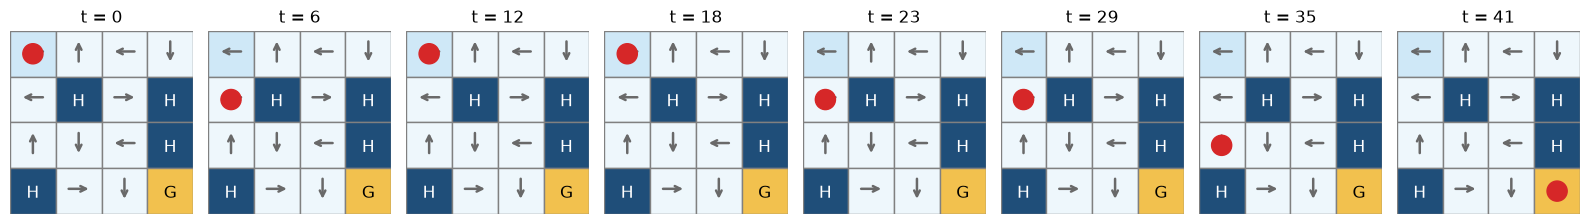

In [9]:
picks = np.linspace(0, len(states) - 1, 8).round().astype(int)
fig, axes = plt.subplots(1, 8, figsize=(16, 2.6))
for ax, t in zip(axes, picks):
    draw_lake(ax, desc, state=states[t], policy=q_policy, title=f"t = {t}")
fig.tight_layout()
fig.savefig(FIGURES / "ch03_walk_frames.png", dpi=80)
plt.show()

**期待する結果**（上の出力の読み方。seed = 1 の場合）: 41 歩の道のりから、等間隔に 8 枚を選んだコマ送りです。赤い丸がエージェントの位置、矢印が学習後の方策が各マスで選ぶ向きです。`t = 0`〜`29` は左上の 0・4 にいて、`t = 35` で 8 に、`t = 41` でゴールの 15 に着いています。

### 4-4. 学習曲線を見る

学習中のエピソードごとの報酬（ゴールに着けば 1、着かなければ 0）を、直前 100 回の平均にして描きます。この平均は、その時点の「ゴールに着いた割合」です。

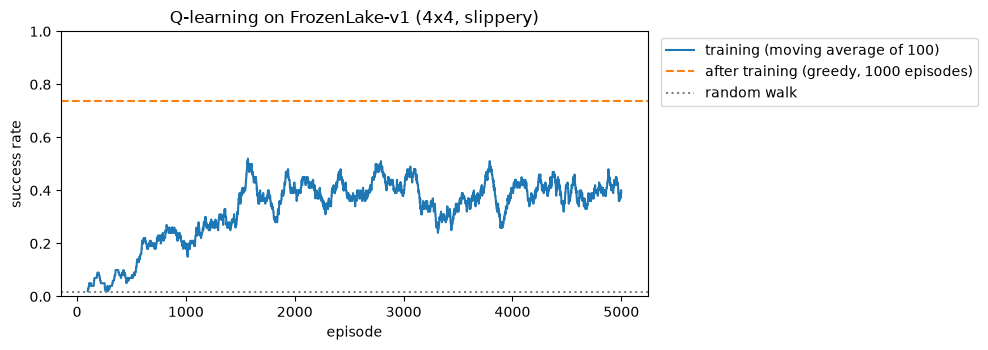

In [10]:
window = 100
moving = np.convolve(train_rewards, np.ones(window) / window, mode="valid")

fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(np.arange(window - 1, len(train_rewards)), moving, color="tab:blue", label=f"training (moving average of {window})")
ax.axhline(q_rate, color="tab:orange", linestyle="--", label="after training (greedy, 1000 episodes)")
ax.axhline(random_rate, color="gray", linestyle=":", label="random walk")
ax.set_xlabel("episode")
ax.set_ylabel("success rate")
ax.set_ylim(0, 1)
ax.set_title("Q-learning on FrozenLake-v1 (4x4, slippery)")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1))
fig.tight_layout()
fig.savefig(FIGURES / "ch03_learning_curve.png", dpi=80)
plt.show()

**期待する結果**（上の出力の読み方）: 青い線が学習中のゴールに着いた割合（直前 100 回の平均）、橙の破線が4-2節で測った学習後の成績（73.6%）、灰色の点線がでたらめに歩いた場合（1.7%）です。青い線は、最初の 500 回ほどは 10% 以下で、そこから上がっていき、1,500 回あたりからは 30〜50% の間を上下しています。学習の終わりまで、橙の破線には届きません。

学習中の成績が、学習後の成績より低いままなのは、学習中は確率 0.1 ででたらめな行動を混ぜているためです（6-1節の ε-greedy）。著者が、学習後の方策に同じ割合でたらめな行動を混ぜて 1,000 回歩かせたところ、ゴールに着いた割合は 35.4% で、学習中の最後の 500 回（39.4%）に近い値でした。

## 5. 読む(1)：Q 表

4節で学んだ Q 表の中身を見ます。行が状態（0〜15）、列が行動（`LEFT`・`DOWN`・`RIGHT`・`UP`）です。

In [11]:
print("状態    LEFT   DOWN  RIGHT     UP   選ぶ向き")
for s in range(16):
    letter = desc.flat[s].decode()
    choice = ACTION_NAMES[q_policy[s]] if letter in "SF" else f"({letter})"
    print(f"{s:4d}  " + "  ".join(f"{q:5.3f}" for q in q_table[s]) + f"   {choice}")

状態    LEFT   DOWN  RIGHT     UP   選ぶ向き
   0  0.533  0.520  0.525  0.517   LEFT
   1  0.166  0.196  0.306  0.469   UP
   2  0.393  0.293  0.283  0.319   LEFT
   3  0.039  0.181  0.000  0.034   DOWN
   4  0.553  0.436  0.452  0.366   LEFT
   5  0.000  0.000  0.000  0.000   (H)
   6  0.213  0.194  0.283  0.125   RIGHT
   7  0.000  0.000  0.000  0.000   (H)
   8  0.317  0.476  0.492  0.600   UP
   9  0.551  0.644  0.537  0.378   DOWN
  10  0.594  0.430  0.436  0.183   LEFT
  11  0.000  0.000  0.000  0.000   (H)
  12  0.000  0.000  0.000  0.000   (H)
  13  0.309  0.622  0.699  0.537   RIGHT
  14  0.705  0.851  0.803  0.705   DOWN
  15  0.000  0.000  0.000  0.000   (G)


**期待する結果**（上の出力の読み方）: 穴（`(H)`）とゴール（`(G)`）の行は、すべて 0 です。そこに着いた時点でエピソードが終わり、その状態から行動を選ぶことが無いので、一度も書き換えられないためです。それ以外の行では、4つの Q 値のうち最大のものが「選ぶ向き」になります。たとえば状態 14（ゴールの左隣）では、`DOWN`（0.851）が最大で、ゴールのある `RIGHT`（0.803）を上回っています。

表の数字だけでは分かりにくいので、各マスで最大の Q 値（その状態の価値の見積もり）と、選ぶ向きを地図に書き込みます。

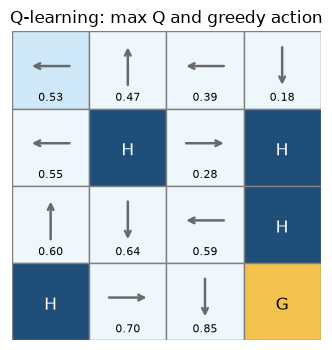

In [12]:
fig, ax = plt.subplots(figsize=(3.6, 3.6))
draw_lake(ax, desc, values=q_table.max(axis=1), policy=q_policy, title="Q-learning: max Q and greedy action")
fig.tight_layout()
fig.savefig(FIGURES / "ch03_q_policy.png", dpi=80)
plt.show()

**期待する結果**（上の出力の読み方）: 地図の上に、各マスの最大の Q 値（下の数）と、選ぶ向き（矢印）が書き込まれます。ゴールに近いマスほど値が大きく（14 で 0.85、13 で 0.70）、スタートの 0 では 0.53 です。

ゴールの左隣の 14 で、ゴールのある右（`RIGHT`）ではなく下（`DOWN`）を選ぶのは、不思議に見えるかもしれません。滑る湖では、選んだ向きの左右へも滑ることを思い出してください。14 で `DOWN` を選ぶと、行き先は「下（湖の端なので 14 にとどまる）」「左の 13」「右のゴール 15」のどれかです。`RIGHT` を選ぶと、「右のゴール 15」「上の 10」「下（14 にとどまる）」のどれかです。どちらもゴールへ行く確率は 1/3 で、違うのは、13 へ滑るか 10 へ滑るかです。7節で湖の仕組みから計算した価値（7-2節の図）でも、13（0.74）のほうが 10（0.62）より高く、`DOWN` のほうが良い選び方になっています。

4-3節で見た、状態 0・4 で `LEFT` を選び続ける動きも、同じように読めます。状態 4 は、右隣が穴の 5 です。`LEFT` を選ぶと、行き先は 0・4・8 のどれかで、穴の 5 へは決して滑りません。`DOWN`・`RIGHT`・`UP` のどれを選んでも、確率 1/3 で 5 へ進むか滑るかします。遠回りでも穴に落ちない選び方を、Q学習は試行錯誤だけで見つけていたわけです。

## 6. 読む(2)：Q学習のサンプル

4-1節のサンプルを、上から順に読みます。

### 6-1. 行動の選び方（ε-greedy）

```python
if rng.random() < epsilon:
    action = int(rng.integers(env.action_space.n))
else:
    action = greedy_action(q_table, state, rng)
```

概要資料の3-1節で紹介した **ε-greedy** です。`rng.random()` は 0 以上 1 未満の数をでたらめに1つ返すので、確率 `epsilon`（既定は 0.1）で、でたらめな行動を選びます（探索）。残りの 0.9 の確率で、今の Q 表で最も良さそうな行動を選びます（活用）。この章では `epsilon` を学習の間ずっと同じ値にしています。学習が進むにつれて小さくしていくやり方は、第5章で扱う予定です。

`greedy_action` は、Q 値が最大の行動を選ぶ関数です。学習の始めは Q 表がすべて 0 なので、4つの行動がすべて「最大」になります。NumPy の `argmax` は、最大が複数あると最初のもの（ここでは `LEFT`）を返すので、そのまま使うと、学習の始めにいつも左ばかり選んでしまいます。`greedy_action` は、最大の行動が複数あるときは、その中からでたらめに選ぶようにしています。

### 6-2. 表を書き換える1行（Q学習の更新）

```python
target = reward if terminated else reward + gamma * q_table[next_state].max()
q_table[state, action] += alpha * (target - q_table[state, action])
```

Q学習の中心は、この2行です。式で書くと次のようになります。$s$ は今の状態、$a$ は選んだ行動、$r$ は得た報酬、$s'$ は次の状態です。

$$Q(s, a) \leftarrow Q(s, a) + \alpha \left( r + \gamma \max_{a'} Q(s', a') - Q(s, a) \right)$$

- **目標**（`target`）: 「今得た報酬」と「次の状態で最も良い行動を選んだときの Q 値を、割引率 $\gamma$（`gamma`）倍したもの」の和です。1歩先の見積もりを使って、今の見積もりの答え合わせをします
- **ずれ**（`target - q_table[state, action]`）: 目標と今の Q 値の差です
- **学習率** $\alpha$（`alpha`、既定は 0.1）: ずれのうち、どれだけを Q 値に反映させるかの割合です。滑る湖では、同じ状態で同じ行動を選んでも行き先が毎回変わるので、1回の経験で Q 値を目標まで一気に動かさず、少しずつ動かして、いろいろな行き先の平均に近づけます

`terminated` のとき（穴に落ちた、ゴールに着いた）は、その先がもう無いので、目標は報酬だけです。一方、`truncated`（100 回の上限で打ち切られた）のときは、本当はその先も続けられたはずなので、次の状態の Q 値を足します。第2章の5-1節で見た、2つの終わり方の違いを使っている所です。

次の状態の Q 値として、実際に次に選ぶ行動（ε-greedy で、でたらめに選ぶこともある）ではなく、最も良い行動の Q 値（`max`）を使うのが、Q学習の特徴です。経験を集める方策（ε-greedy）と、学ぼうとしている方策（いつも最も良い行動を選ぶ方策）が別なので、Q学習は**方策オフ**の手法に分類されます（概要資料の3-3節）。実際に次に選ぶ行動の Q 値を使う SARSA という手法もあり、第4章で Q学習と比べる予定です。

### 6-3. 数字で確かめる

4節で学んだ Q 表を使って、更新の1回分を手で計算してみます。Q 表そのものは書き換えないように、値を取り出して計算します。

In [13]:
alpha, gamma = 0.1, 0.99

# 例1: 状態 14 で RIGHT を選び、ゴール（状態 15）に着いて報酬 1 を得た（terminated）
before = q_table[14, 2]
target = 1.0
print(f"例1: 今の Q(14, RIGHT) = {before:.3f}, 目標 = {target:.3f}, 更新後 = {before + alpha * (target - before):.3f}")

# 例2: 状態 13 で RIGHT を選び、状態 14 へ進んで報酬 0 を得た（まだ続く）
before = q_table[13, 2]
target = 0.0 + gamma * q_table[14].max()
print(f"例2: 今の Q(13, RIGHT) = {before:.3f}, 目標 = {target:.3f}, 更新後 = {before + alpha * (target - before):.3f}")

# 例3: 状態 13 で RIGHT を選んだが、滑って状態 9 へ進んで報酬 0 を得た
target = 0.0 + gamma * q_table[9].max()
print(f"例3: 今の Q(13, RIGHT) = {before:.3f}, 目標 = {target:.3f}, 更新後 = {before + alpha * (target - before):.3f}")

例1: 今の Q(14, RIGHT) = 0.803, 目標 = 1.000, 更新後 = 0.823
例2: 今の Q(13, RIGHT) = 0.699, 目標 = 0.843, 更新後 = 0.713
例3: 今の Q(13, RIGHT) = 0.699, 目標 = 0.638, 更新後 = 0.693


**期待する結果**（上の出力の読み方）: 例1は、ゴールに着いた場合です。`terminated` なので先が無く、目標は報酬の 1 だけです。今の Q 値 0.803 が、目標とのずれ（0.197）の 1 割だけ目標へ近づいて、0.823 になります。

例2は、ゴールに近いマスへ進めた場合で、目標は「報酬 0 ＋ 0.99 × 状態 14 の最大の Q 値（0.851）」で 0.843 です。今の Q 値（0.699）より大きいので、Q 値は 0.713 に上がります。

例3は、同じ「13 で `RIGHT`」でも、滑って状態 9 へ行った場合です。目標は 0.99 × 0.644（状態 9 の最大の Q 値）で 0.638 と、今の Q 値より小さいので、Q 値は 0.693 に下がります。同じ行動でも、滑り方しだいで Q 値は上がったり下がったりします。

## 7. 読む(3)：湖の仕組みが分かっているとき

Q学習は、湖の仕組み（どこへどれだけの確率で滑るか）を知らないまま、歩き回った経験だけから学びました。ところが FrozenLake では、その仕組みを Gymnasium から直接読み出せます。仕組みが分かっていれば、歩き回らなくても、計算だけで各マスの価値と最も良い方策を求められます。

### 7-1. 行き先と確率の表 `P` を見る

In [14]:
P = env.unwrapped.P
print("状態 14 で RIGHT を選んだときの行き先:")
for prob, next_state, reward, terminated in P[14][2]:
    print(f"  確率 {prob:.3f} で状態 {next_state:2d} へ、報酬 {reward}、terminated={terminated}")
print("状態 5（穴）で LEFT を選んだときの行き先:", P[5][0])

状態 14 で RIGHT を選んだときの行き先:
  確率 0.333 で状態 14 へ、報酬 0、terminated=False
  確率 0.333 で状態 15 へ、報酬 1、terminated=True
  確率 0.333 で状態 10 へ、報酬 0、terminated=False
状態 5（穴）で LEFT を選んだときの行き先: [(1.0, 5, 0, True)]


**期待する結果**（上の出力の読み方）: 状態 14 で `RIGHT` を選ぶと、確率 1/3 ずつで、14 にとどまる（下へ滑って湖の端に当たる）、ゴールの 15 へ進む（報酬 1、`terminated=True`）、上の 10 へ滑る、のどれかになります。3-3節で数えた滑り方と同じ決まりです。`P[状態][行動]` は、`(確率, 次の状態, 報酬, terminated)` の組の一覧です。

穴の状態 5 では、どの行動を選んでも、確率 1 で 5 のままで、報酬は 0 です。エピソードはそこで終わっているので、実際にこの行が使われることはありません。

### 7-2. 価値反復

**価値反復**は、すべての状態の価値 $V(s)$ を 0 から始めて、次の式で何度も更新し、変化がほとんど無くなったら止める方法です。

$$V(s) \leftarrow \max_{a} \sum_{s'} p(s' \mid s, a) \left( r + \gamma V(s') \right)$$

$p(s' \mid s, a)$ は、状態 $s$ で行動 $a$ を選んだときに状態 $s'$ へ行く確率で、7-1節の `P` から読み出せます。右辺の $\sum$ の部分は、「行き先ごとに、確率 ×（報酬 + 割引した行き先の価値）を足し合わせたもの」で、行動 $a$ の Q 値に当たります。Q学習の目標は、実際に滑って着いた1つの行き先だけで計算しましたが、価値反復は、すべての行き先を確率で重み付けして一度に計算します。このように、価値どうしの関係を表した式を**ベルマン方程式**と呼びます。

In [15]:
# 価値 V から、各状態・各行動の Q 値を計算する（行き先ごとに「確率 ×（報酬 + 割引した行き先の価値）」を足す）
def q_from_v(P, V, gamma):
    q = np.zeros((len(P), len(P[0])))
    for s in P:
        for a in P[s]:
            for prob, next_state, reward, terminated in P[s][a]:
                q[s, a] += prob * (reward + (0 if terminated else gamma * V[next_state]))
    return q


# 価値反復: すべての状態の価値を、変化が theta より小さくなるまで更新し、価値・方策・更新の回数を返す
def value_iteration(P, gamma=0.99, theta=1e-8):
    V = np.zeros(len(P))
    for sweep in itertools.count(1):
        q = q_from_v(P, V, gamma)
        new_V = q.max(axis=1)
        if np.abs(new_V - V).max() < theta:
            return new_V, q.argmax(axis=1), sweep
        V = new_V


start = time.perf_counter()
vi_values, vi_policy, sweeps = value_iteration(P)
print(f"更新の回数: {sweeps}  かかった時間: {time.perf_counter() - start:.2f} 秒")
vi_rate = success_rate(env, vi_policy)
print(f"価値反復の方策でゴールに着いた割合: {vi_rate:.1%}")
print(f"Q学習の方策でゴールに着いた割合:   {q_rate:.1%}")
print("方策が違う状態:", [s for s in range(16) if desc.flat[s] in b"SF" and vi_policy[s] != q_policy[s]])

更新の回数: 438  かかった時間: 0.04 秒


価値反復の方策でゴールに着いた割合: 73.8%
Q学習の方策でゴールに着いた割合:   73.6%
方策が違う状態: [2, 3, 6]


**期待する結果**（上の出力の読み方）: 価値反復は 438 回の更新で止まり、かかった時間は 0.04 秒でした（4節の Q学習は 3.9 秒）。求めた方策でゴールに着いた割合は 73.8% で、Q学習の 73.6% とほぼ同じです。方策が違うのは、状態 2・3・6 の3つだけです。

`value_iteration` の中の `q_from_v` が、上の式の $\sum$ の部分、つまり「行き先ごとに確率 ×（報酬 + 割引した行き先の価値）を足し合わせる」計算です。`q.max(axis=1)` で各状態の最大を取ったものが、新しい価値になります。止まった後の `q.argmax(axis=1)` が、各状態で Q 値が最大の行動、つまり求めた方策です。

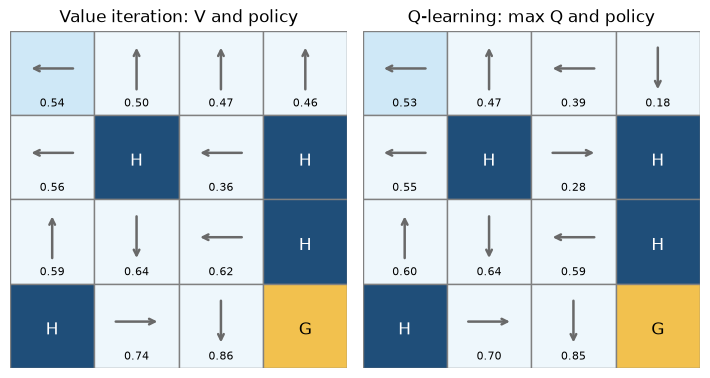

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.8))
draw_lake(axes[0], desc, values=vi_values, policy=vi_policy, title="Value iteration: V and policy")
draw_lake(axes[1], desc, values=q_table.max(axis=1), policy=q_policy, title="Q-learning: max Q and policy")
fig.tight_layout()
fig.savefig(FIGURES / "ch03_vi_vs_q.png", dpi=80)
plt.show()

**期待する結果**（上の出力の読み方）: 左が価値反復で求めた価値 $V$ と方策、右が Q学習の最大の Q 値と方策です。スタートからゴールへ、左側を下りていく道筋のマス（0・4・8・9・13・14）は、値も向きもよく似ています。違いが大きいのは右上の 2・3 で、Q学習の値（0.39・0.18）は価値反復の値（0.47・0.46）より小さく、向きも違います。

右上のマスで違いが大きいのは、Q学習がそこをあまり経験していないためです。著者が4節と同じ学習で各状態を訪れた回数を数えたところ、状態 0 は 44,502 回だったのに対し、状態 2 は 2,181 回、状態 3 は 77 回でした。Q学習は、経験した所の Q 値しか書き換えられません。学習後の方策は、スタートから左側を下りていく道を選ぶので、右上のマスの向きが価値反復と違っていても、4-2節の成績は価値反復とほぼ同じでした。

状態 6 は、左も右も隣が穴です。`LEFT` を選んでも `RIGHT` を選んでも、行き先は「穴へ 1/3、上の 2 へ 1/3、下の 10 へ 1/3」で、どちらも同じ価値になります。価値反復の `argmax` は同じ値のうち最初の `LEFT` を、Q学習は経験で少しだけ大きくなった `RIGHT` を選んでいます。

### 7-3. 方策反復

**方策反復**は、もう1つの計算の方法です。適当な方策（ここでは、すべてのマスで `LEFT`）から始めて、次の2つを、方策が変わらなくなるまで繰り返します。

1. **評価**: 今の方策に従ったときの、各状態の価値を求める
2. **改善**: 各状態で、1で求めた価値から計算した Q 値が最大の行動に、方策を改める

In [17]:
# 方策反復: 方策の評価と改善を、方策が変わらなくなるまで繰り返し、価値・方策・繰り返しの回数を返す
def policy_iteration(P, gamma=0.99, theta=1e-8):
    n_states = len(P)
    policy = np.zeros(n_states, dtype=int)
    for round_ in itertools.count(1):
        V = np.zeros(n_states)
        while True:  # 評価: 今の方策の行動だけを使って、価値の更新を繰り返す
            new_V = q_from_v(P, V, gamma)[np.arange(n_states), policy]
            if np.abs(new_V - V).max() < theta:
                break
            V = new_V
        new_policy = q_from_v(P, new_V, gamma).argmax(axis=1)  # 改善
        if np.array_equal(new_policy, policy):
            return new_V, policy, round_
        policy = new_policy


pi_values, pi_policy, rounds = policy_iteration(P)
print("評価と改善を繰り返した回数:", rounds)
print("価値反復と同じ方策か:", np.array_equal(pi_policy, vi_policy))
print("価値の差の最大:", f"{np.abs(pi_values - vi_values).max():.1e}")

評価と改善を繰り返した回数: 7
価値反復と同じ方策か: True
価値の差の最大: 1.3e-09


**期待する結果**（上の出力の読み方）: 方策反復は、評価と改善を 7 回繰り返して止まり、価値反復と同じ方策になりました。価値の差の最大も 1.3e-09（10 億分の 1.3）で、計算の誤差の範囲です。2つの方法は、同じ答え（割引率 0.99 のもとで最も良い方策）にたどり着いています。

### 7-4. Q学習と価値反復を比べる

| | Q学習（4〜6節） | 価値反復・方策反復（7節） |
|---|---|---|
| 使う情報 | 歩き回った経験だけ | 湖の仕組み（行き先と確率の表 `P`） |
| 分類 | モデルフリー | モデルベース（動的計画法） |
| 見積もる表 | Q 表（16 × 4） | 価値 $V$（16 個）。Q 値は $V$ から計算できる |
| 結果 | 試行錯誤の運しだいで、少しずつ近づく | 決まった答えが計算で求まる |

価値反復と方策反復は、大きな問題を、小さな部分問題（各状態の価値）の答えを使い回しながら解く**動的計画法**の一種です。ただし、使えるのは、環境の仕組みが分かっていて、しかも状態の数が表に書ききれるほど少ない場合だけです。多くの環境では、仕組みは分からず、経験から学ぶしかありません。この教科書のこれから先の章の多くは、Q学習のような、経験から学ぶ手法を使います。

## 8. 遊んでみる

### 8-1. 滑らない湖

`is_slippery=False` を指定すると、氷が滑らなくなり、選んだ向きへ必ず進めます。価値反復と Q学習で解いてみます。Q学習のエピソードは、4節の 5 分の 1 の 1,000 回にします。

価値反復の更新の回数: 7
価値反復の方策でゴールに着いた割合: 100.0%
Q学習（1,000 回）の方策でゴールに着いた割合: 100.0%
Q学習の学習中、最後の 100 回でゴールに着いた割合: 95.0%


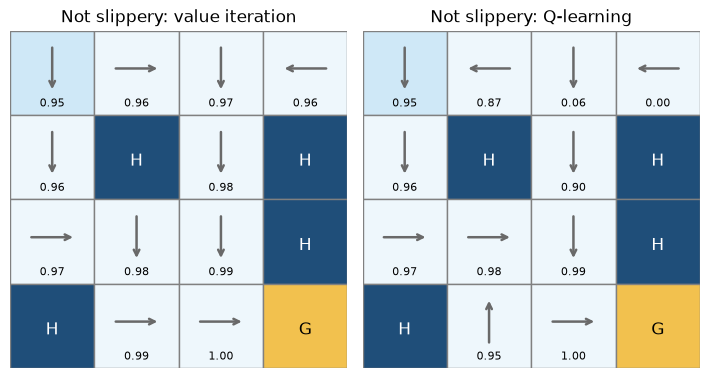

In [18]:
calm = gym.make("FrozenLake-v1", is_slippery=False)
calm_values, calm_vi_policy, calm_sweeps = value_iteration(calm.unwrapped.P)
calm_q_table, calm_rewards = q_learning(calm, episodes=1000)
calm_q_policy = calm_q_table.argmax(axis=1)
print("価値反復の更新の回数:", calm_sweeps)
print(f"価値反復の方策でゴールに着いた割合: {success_rate(calm, calm_vi_policy):.1%}")
print(f"Q学習（1,000 回）の方策でゴールに着いた割合: {success_rate(calm, calm_q_policy):.1%}")
print(f"Q学習の学習中、最後の 100 回でゴールに着いた割合: {calm_rewards[-100:].mean():.1%}")

fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.8))
draw_lake(axes[0], desc, values=calm_values, policy=calm_vi_policy, title="Not slippery: value iteration")
draw_lake(axes[1], desc, values=calm_q_table.max(axis=1), policy=calm_q_policy, title="Not slippery: Q-learning")
fig.tight_layout()
plt.show()

**期待する結果**（上の出力の読み方）: 滑らない湖では、価値反復は 7 回の更新で止まり、価値反復の方策も、1,000 回だけ学んだ Q学習の方策も、100% ゴールに着きます。Q学習の学習中も、最後の 100 回で 95.0% です。図の左右とも、スタートからの矢印は、最短の 6 歩の道をたどっています（左は 4 → 8 → 9 → 13 → 14 → 15、右は 4 → 8 → 9 → 10 → 14 → 15）。

左の図のスタートの価値 0.95 は、6 歩目に得る報酬 1 を、割引率 0.99 で 5 回割り引いた値（0.99⁵ ≈ 0.951）です。右の図では、右上の 2・3 の値（0.06・0.00）が、左の図の値（0.97・0.96）と大きく違います。7-2節の滑る湖と同じく、Q学習の見積もりが粗いのは右上のマスです。

### 8-2. 割引率を変える

割引率 $\gamma$ は、遠い先の報酬をどれだけ重んじるかを決める数でした（概要資料の2節）。滑る湖で、$\gamma$ を 0.99・0.9・0.5 に変えて価値反復で解き、方策と成績を比べます。

In [19]:
for g in [0.99, 0.9, 0.5]:
    values, policy, sweeps = value_iteration(P, gamma=g)
    first_row = " ".join(ACTION_NAMES[a] for a in policy[:4])
    print(f"gamma = {g:4}: 更新 {sweeps:3d} 回、スタートの価値 {values[0]:.3f}、"
          f"ゴールに着いた割合 {success_rate(env, policy):5.1%}、1行目（状態 0〜3）の向き: {first_row}")

gamma = 0.99: 更新 438 回、スタートの価値 0.542、ゴールに着いた割合 73.8%、1行目（状態 0〜3）の向き: LEFT UP UP UP


gamma =  0.9: 更新 112 回、スタートの価値 0.069、ゴールに着いた割合 73.2%、1行目（状態 0〜3）の向き: LEFT UP LEFT UP


gamma =  0.5: 更新  22 回、スタートの価値 0.000、ゴールに着いた割合 45.0%、1行目（状態 0〜3）の向き: DOWN UP RIGHT UP


**期待する結果**（上の出力の読み方）: γ = 0.99 と 0.9 では、成績はほぼ同じ（73.8%・73.2%）ですが、γ = 0.5 では 45.0% まで下がります。スタートの価値も、γ が小さいほど小さく、γ = 0.5 では小数第3位までで 0.000 です。1行目（状態 0〜3）の向きも、γ によって変わります。

γ = 0.5 では、1歩遠くなるごとに報酬の重みが半分になります。ゴールまで何歩もかかるスタートの付近では、遠い先のゴールの報酬がほとんど数えられません（著者が確かめたところ、スタートの価値は 0.00038 でした）。この湖では、目先の報酬を重んじすぎると、成績が下がる例になっています。

### 8-3. 大きな湖

`map_name="8x8"` を指定すると、8 × 8（64 マス）の湖になります。エピソードの上限は 200 回に増えます。価値反復と、4節と同じ設定の Q学習（5,000 回）で解いてみます。著者の環境では、このセル全体で 12 秒ほどかかりました。

Q学習にかかった時間: 9 秒


価値反復（更新 516 回）の方策でゴールに着いた割合: 64.7%


Q学習（5,000 回）の方策でゴールに着いた割合: 58.1%


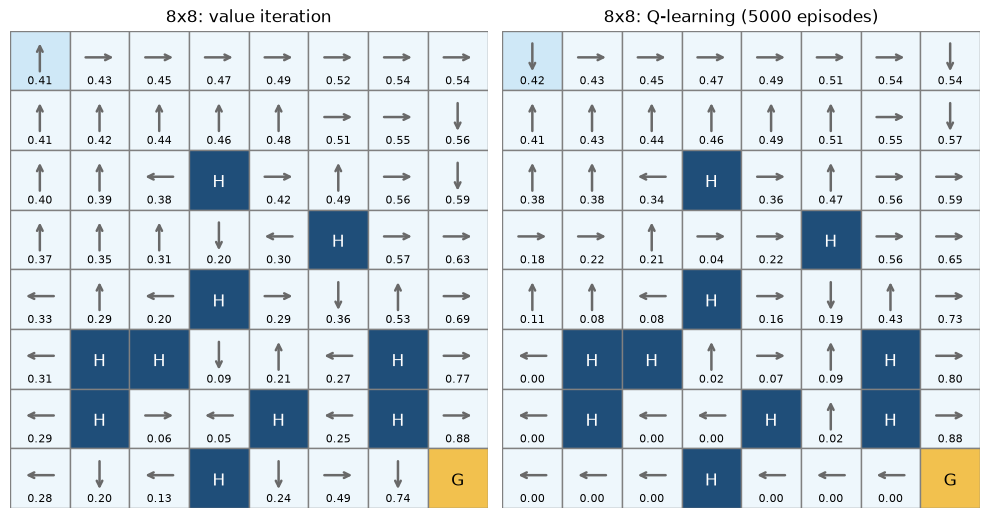

In [20]:
big = gym.make("FrozenLake-v1", map_name="8x8")
big_values, big_vi_policy, big_sweeps = value_iteration(big.unwrapped.P)
start = time.perf_counter()
big_q_table, big_rewards = q_learning(big, episodes=5000)
print(f"Q学習にかかった時間: {time.perf_counter() - start:.0f} 秒")
print(f"価値反復（更新 {big_sweeps} 回）の方策でゴールに着いた割合: {success_rate(big, big_vi_policy):.1%}")
print(f"Q学習（5,000 回）の方策でゴールに着いた割合: {success_rate(big, big_q_table.argmax(axis=1)):.1%}")

fig, axes = plt.subplots(1, 2, figsize=(10, 5.2))
draw_lake(axes[0], big.unwrapped.desc, values=big_values, policy=big_vi_policy, title="8x8: value iteration")
draw_lake(axes[1], big.unwrapped.desc, values=big_q_table.max(axis=1), policy=big_q_table.argmax(axis=1),
          title="8x8: Q-learning (5000 episodes)")
fig.tight_layout()
plt.show()

**期待する結果**（上の出力の読み方）: 8 × 8 の湖では、価値反復の方策が 64.7%、Q学習（5,000 回）の方策が 58.1% で、4 × 4 の湖と違い、Q学習は価値反復に届いていません。Q学習にかかった時間は 9 秒で、4 × 4 の湖（3.9 秒）より長くなっています。

図の左右を比べると、上の行や右の列の矢印と値はよく似ていますが、左下の一帯は、Q学習の値がほとんど 0.00 で、価値反復の値（0.05〜0.31）と違います。

**やってみよう**:

- 4-1節の `q_learning(env, episodes=5000)` を `q_learning(env, episodes=5000, epsilon=0.3)` に変えて、そこから下を実行し直してみてください。著者が学習の seed を 0〜4 に変えて試したところ、`epsilon=0.3` では、学習後の成績が 53.9〜73.8% と seed によって大きく上下しました（`epsilon=0.1` では 73.2〜73.6%）
- 8-3節の Q学習のエピソードを 20,000 回に増やしてみてください。著者が試したところ、成績は 54.0% で、5,000 回（58.1%）より上がりませんでした（時間は 42 秒でした）。経験を増やせば必ず良くなるわけではないことが分かります
- `gym.make("FrozenLake-v1", desc=["SFFF", "FHFH", "FFFH", "HFFG"])` のように、`desc` に文字列を並べると、地図を自分で作れます（この例は、4 × 4 の既定の地図と同じです）。穴の位置を変えて、価値反復の方策がどう変わるかを見てみましょう

## 9. まとめ

この章では、FrozenLake を、表を使う2つのやり方で解きました。

| したこと | 使ったもの | 節 |
|---|---|---|
| 湖の地図・滑り方・でたらめな歩きの成績を見る | `desc`、`step()` | 3節 |
| Q学習で学ばせ、成績・歩く様子・学習曲線を見る | `q_learning()`、`success_rate()` | 4節 |
| Q 表を読む | `q_table`、`argmax` | 5節 |
| Q学習の更新を読む | ε-greedy、更新の式 | 6節 |
| 湖の仕組みから計算で解く | `P`、`value_iteration()`、`policy_iteration()` | 7節 |
| 滑らない湖・割引率・大きな湖で試す | `is_slippery`、`gamma`、`map_name` | 8節 |

Q学習は、湖の仕組みを知らないまま、5,000 回の試行錯誤だけで、仕組みを使って計算した答え（価値反復）とほぼ同じ成績の方策を見つけました。滑る湖では、遠回りでも穴に落ちない道を選ぶことも、自分で見つけています。一方で、あまり訪れないマスの見積もりは粗いままで、8 × 8 の大きな湖では、5,000 回の経験では計算の答えに届きませんでした。

経験から学ぶ手法では、どんな方策で経験を集めるかが、学んだ結果に響きます。第4章では、崖のそばを歩く CliffWalking で、Q学習と、実際に次に選ぶ行動の Q 値を使う SARSA（6-2節）を比べる予定です。

- 次に読むもの: 第4章 CliffWalking（準備中）。崖のそばを歩く環境で、Q学習と SARSA が選ぶ道の違いを見る予定です
- 手法の位置づけを見直したいときは、概要資料の[強化学習](../../overview/rl.md)に戻ってください

<!-- TODO（著者用）: 第4章ができたらリンクにする -->

## 出典

この章は、次の文献・公式の文書と、導入した Gymnasium 1.3.0 の動作（2026-10-09 確認）をもとに、著者の言葉でまとめたものです。逐語の転載ではありません。サンプルのコードは著者が書いたものです。

- R. S. Sutton and A. G. Barto, *Reinforcement Learning: An Introduction*, 2nd edition, MIT Press, 2018（第4章 動的計画法、第6章 TD 学習〈Q学習〉）
- C. J. C. H. Watkins and P. Dayan, "Q-learning", *Machine Learning*, 8, 279–292, 1992
- Farama Foundation, Gymnasium Documentation, Frozen Lake: https://gymnasium.farama.org/environments/toy_text/frozen_lake/
- Farama Foundation, Gymnasium 1.3.0 のソース `gymnasium/envs/toy_text/frozen_lake.py`（行き先と確率の表 `P`、描画に使う画像素材の作者の表記）: https://github.com/Farama-Foundation/Gymnasium/blob/v1.3.0/gymnasium/envs/toy_text/frozen_lake.py

この章の図と GIF は、著者が matplotlib で描いたものです（Gymnasium の描画の絵は使っていません）。この教科書のライセンスと、使っている第三者のソフトウェアの一覧は、リポジトリの [LICENSE.md](../../LICENSE.md) にあります。